# Document embeddings with Doc2Vec

Just as numerical representations of words can be learned, it is also possible to learn numerical representations of documents. The term document is used here as a general interpretation of various related texts such as sentences, sections, pages or documents. Modern language models aim to learn numerical representations of documents which capture semantic meaning as well as inherent relationships of tokens within the document. While we approach more sophisticated language models at a later stage of this course, we start with two variants which are natural additions to the Word2Vec variants of the last section.

## Doc2Vec

In this [paper](https://arxiv.org/abs/1405.4053), the authors demonstrate how Word2Vec approaches can be adjusted to learn numerical representations of documents. The picture below repeats the CBOW and SG variants of Word2Vec. While CBOW uses surrounding words in the context of a center word to predict the center word, SG aims to predict the surrounding words by the center word. Independent of the variant, words are represented by vectors which can be used to determine word occurrence probabilities. 

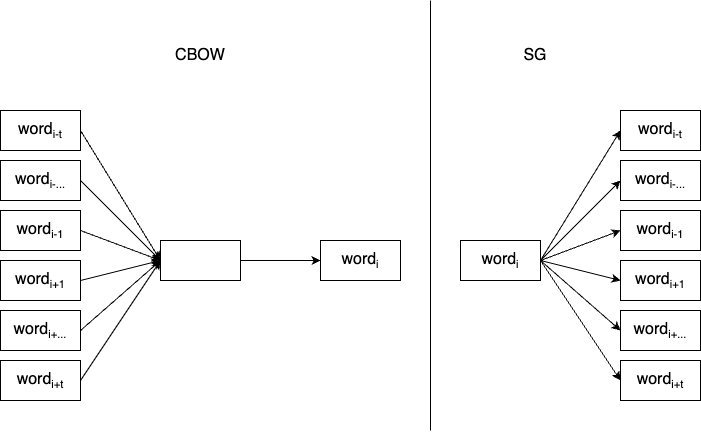

In [1]:
from IPython.display import Image
Image(filename='cbow_sg.png') 

Below we see how the Doc2Vec variants distributed memory of paragraph vectors (PV-DM) and distributed bag of words version of paragraph vectors (PV-DBOW) look like. The PV-DM approach is build in analogy to the CBOW model. It works in the same way, however, a document specific vector is added to the vectors of the surrounding words to predict the center word in a part of the document text. The PV-DBOW is created in analogy to the SG model. Given a document, we use its vector to predict the occurence of a word in the document. 

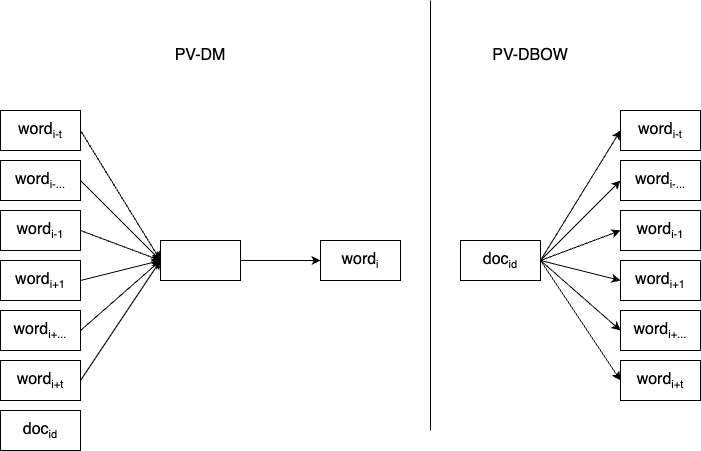

In [2]:
from IPython.display import Image
Image(filename='pv_dm_pv_cbow.png') 

### PV-DM and DV-BOW

Let us go back to our example from the last section. We can proceed as we did before, however, we now have three sentences in the corpus where each is interpreted as a document. This means besides the word ids, we use document ids to convert each word and each document into unique vectors which are initialized randomly in the beginning.

In [3]:
from gensim.utils import simple_preprocess
import numpy as np
import tensorflow as tf


raw_corpus = [
    "The dog would like a piece of the sandwich",
    "I like to eat ice-cream",
    "A dog is a good friend"
]

corpus = [simple_preprocess(doc, min_len = 1) for doc in raw_corpus]

word2index = dict()
doc2index = dict()
idx = 0
for i, doc in enumerate(corpus):
    doc2index[" ".join(doc)] = i
    for word in doc:
        if word in word2index.keys():
            continue
        else:
            word2index[word] = idx
            idx += 1


print(word2index)
print(doc2index)

{'the': 0, 'dog': 1, 'would': 2, 'like': 3, 'a': 4, 'piece': 5, 'of': 6, 'sandwich': 7, 'i': 8, 'to': 9, 'eat': 10, 'ice': 11, 'cream': 12, 'is': 13, 'good': 14, 'friend': 15}
{'the dog would like a piece of the sandwich': 0, 'i like to eat ice cream': 1, 'a dog is a good friend': 2}


See below how we randomly generate a word embedding matrix for surrounding words ($W$), one for center words ($V$) and one for document embeddings ($D$).

In [4]:
# number of words
d = len(word2index)
# number of documents 
docs = len(doc2index)
# dimensions of word and document vectors
p = 4

tf.random.set_seed(42)
W = tf.random.normal((d, p))
print(f"Word embeddings for surrounding words:\n {W} \n")
D = tf.random.normal((docs, p))
print(f"Document embeddings:\n {D} \n")
V = tf.random.normal((p, d))
print(f"Word embeddings for center words:\n {V} \n")

Word embeddings for surrounding words:
 [[ 3.27468514e-01 -8.42625797e-01  3.19433689e-01 -1.40755188e+00]
 [-2.38805985e+00 -1.03924787e+00 -5.57323217e-01  5.39707005e-01]
 [ 1.69943225e+00  2.88936555e-01 -1.50661159e+00 -2.64547437e-01]
 [-5.97224057e-01 -1.91711318e+00 -6.20441437e-01  8.50402296e-01]
 [-4.06047940e-01 -3.02584124e+00  9.05846417e-01  2.98559874e-01]
 [-2.25615546e-01 -7.61644304e-01 -1.89171398e+00 -9.38471198e-01]
 [ 7.78522134e-01 -4.73388970e-01  9.77726936e-01  2.46944040e-01]
 [ 2.05737472e-01 -5.25623322e-01  3.24100167e-01  2.54540909e-02]
 [-1.06384970e-01 -6.36947513e-01  1.16031218e+00  2.50735909e-01]
 [-4.17284966e-01  4.01257783e-01 -1.41454422e+00 -5.93185663e-01]
 [-1.66172135e+00  3.35671932e-01  1.08156286e-01  2.34796807e-01]
 [-5.66687644e-01 -3.58198434e-01  8.86986256e-01  5.27447701e-01]
 [ 7.04022467e-01 -3.34212482e-01  2.16396436e-01 -9.74854469e-01]
 [-2.07576811e-01 -3.64772938e-02 -1.33534443e+00  6.88585579e-01]
 [ 1.11108327e+00  4.0

Just to provide a deeper understanding, let us go through one example: Let us assume, we use a window size of one word, the center word is *dog* from the first document and the surrounding words are *the* and *would*.

In [5]:
# word vectors of the and would
word_vectors = tf.linalg.matmul(tf.keras.utils.to_categorical([0, 2], num_classes = 16), W)
word_vectors

<tf.Tensor: shape=(2, 4), dtype=float32, numpy=
array([[ 0.3274685 , -0.8426258 ,  0.3194337 , -1.4075519 ],
       [ 1.6994323 ,  0.28893656, -1.5066116 , -0.26454744]],
      dtype=float32)>

In [6]:
# document vector for the first document
document_vector = tf.linalg.matmul(tf.keras.utils.to_categorical([0], num_classes = docs), D)
document_vector

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=
array([[ 0.08422458, -0.86090374,  0.37812304, -0.00519627]],
      dtype=float32)>

In [7]:
# concatenate these vectors
word_and_document_vectors = tf.concat([word_vectors, document_vector], axis = 0)
word_and_document_vectors

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[ 0.3274685 , -0.8426258 ,  0.3194337 , -1.4075519 ],
       [ 1.6994323 ,  0.28893656, -1.5066116 , -0.26454744],
       [ 0.08422458, -0.86090374,  0.37812304, -0.00519627]],
      dtype=float32)>

In [8]:
# average these vectors
avg_vector = tf.reduce_mean(word_and_document_vectors, axis = 0)
avg_vector

<tf.Tensor: shape=(4,), dtype=float32, numpy=array([ 0.70370847, -0.471531  , -0.26968494, -0.55909854], dtype=float32)>

In [11]:
# dot product vectors 
probability_scores = tf.linalg.matmul(tf.reshape(avg_vector, shape = (1, -1)), V)
probability_scores

<tf.Tensor: shape=(1, 16), dtype=float32, numpy=
array([[-0.82012826, -0.89800006,  3.0259743 , -1.3077906 , -1.0329028 ,
         0.08797157,  0.3024707 ,  1.2325591 , -0.36871952, -1.2887456 ,
        -0.40856752, -0.5791075 , -0.94469774,  1.4381655 ,  0.18551715,
        -1.6381241 ]], dtype=float32)>

In [12]:
# transform these values to probabilities with the softmax function
probs = tf.nn.softmax(probability_scores)
probs

<tf.Tensor: shape=(1, 16), dtype=float32, numpy=
array([[0.01218002, 0.01126753, 0.5701497 , 0.00747926, 0.00984557,
        0.03020165, 0.03742711, 0.09486775, 0.01912899, 0.00762307,
        0.01838173, 0.01549965, 0.01075345, 0.11652318, 0.03329615,
        0.00537523]], dtype=float32)>

In [13]:
# as the actual center word is dog, the corresponding loss value is
-tf.math.log(probs[0, word2index["dog"]])

<tf.Tensor: shape=(), dtype=float32, numpy=4.485831>

This process is done for all examples which can be build over all documents. Each time the model parameters $W, V, D$ are updated to reduce corresponding losses. If we want to generate document embeddings in PV-DBOW fashion, we can omit $W$ and probability predictions would be given by, e.g.:

In [14]:
# again for instance, given document 1
document_vector

<tf.Tensor: shape=(1, 4), dtype=float32, numpy=
array([[ 0.08422458, -0.86090374,  0.37812304, -0.00519627]],
      dtype=float32)>

In [15]:
# probability scores
probability_scores = tf.linalg.matmul(document_vector, V)
probability_scores

<tf.Tensor: shape=(1, 16), dtype=float32, numpy=
array([[-0.02542165,  0.02067877,  1.6389848 , -0.05846723, -0.65374047,
        -0.8961842 , -0.25603727, -0.5387543 ,  1.4521481 , -1.236344  ,
         0.08411305, -0.02987109, -1.4058074 , -0.04141218, -0.4816858 ,
        -1.0230138 ]], dtype=float32)>

In [16]:
# and the probability prediction 
probs = tf.nn.softmax(probability_scores)
probs

<tf.Tensor: shape=(1, 16), dtype=float32, numpy=
array([[0.05083515, 0.05323353, 0.26853853, 0.04918272, 0.02711994,
        0.02128123, 0.04036538, 0.03042471, 0.22277397, 0.01514493,
        0.05671976, 0.05060946, 0.0127841 , 0.05002873, 0.03221151,
        0.01874629]], dtype=float32)>

If we want to estimate document vectors only, the word parameters do not need to be updated, they can be kept at their initial values after initialization. In this scenario, word vectors are meaningless, however, document vectors will be similar for documents with similar content and vice versa. See below, how we estimate document vectors for our simple example using the gensim library.

In [17]:
from gensim.models import Doc2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


documents = [TaggedDocument(doc, [i]) for i, doc in enumerate(corpus)]
model = Doc2Vec(documents, dm = 0, vector_size=4, window=5, min_count=1, epochs = 5)

doc_vec_sim = pd.DataFrame(cosine_similarity(model.dv.get_normed_vectors()), columns = [f"doc{i+1}" for i in range(len(corpus))], index = [f"doc{i+1}" for i in range(len(corpus))])
doc_vec_sim

,doc1,doc2,doc3
doc1,1.000000,0.184889,0.294504
doc2,0.184889,1.000000,-0.649048
doc3,0.294504,-0.649048,1.000000


However, it is also possible to train an update word vectors during training the document vectors. If we set the *dbow_words* argument to $1$, the documentation states that word vectors are trained by SG, while document vectors are trained by PV-DBOW. The positive side effect of this training procedure is that we generate meaningful word embeddings which can also examined w.r.t. to document similarity. Consequently, we can, e.g., examine how similar the meaning of a document is to the meaning of a word. This characteristic can be employed for topic modeling approaches as demonstrated by [this paper](https://arxiv.org/abs/2008.09470). We come back to this in the next subsection.

## Working with document and word vectors

The cell below imports a Doc2Vec model which is trained using annual 10K form filings from US companies. During the training process, word vectors also have been trained by SG. The first application which comes into mind when working with Doc2Vec is to generate document embeddings. These embeddings can be used for further tasks, e.g., sentiment classification. Besides, document embeddings can be clustered in order to identify topics. Additionally, we can declare a topic of our interest by ourselves with a word list and look for documents which are close to this topic. 

In the cell we also import Apple's 10K filings and split one report into its sentences using the sentence tokenizer from the nltk package. We filter out sentences which are very short or very long and infer the document vector for each sentence. 

In [18]:
import sqlite3
import pandas as pd
from gensim.models.doc2vec import Doc2Vec
from gensim.utils import simple_preprocess
import nltk
import numpy as np
from sklearn.preprocessing import normalize


sent_detector = nltk.data.load('tokenizers/punkt/english.pickle')

# import the Doc2Vec model
d2v = Doc2Vec.load("../language_models/d2v_10K/10K_pvdbow_skipgram_wo_docvecs.pickle")

# load Apple's 10-K filings
conn = sqlite3.connect("../data/dlta_texts.db")
sql_query = "SELECT * FROM filings;"
df_filings = pd.read_sql(sql_query, conn)
apple_filings = df_filings[df_filings.ticker == "AAPL"]
conn.close()

# split the 10K report into sentences
sentences_tmp = sent_detector.tokenize(apple_filings.text[0])
# preprocess the sentences
sentences_tmp = [simple_preprocess(sentence) for sentence in sentences_tmp]
# exclude sentences with word below 15 and above 250
sentences_tmp = [sentence for sentence in sentences_tmp if 15 <= len(sentence) <= 250]

# generate document embeddings for each sentence
doc_vectors = [d2v.infer_vector(sentence) for sentence in sentences_tmp]
# this is optional but I like to normalize the vectors such that they have unit length
doc_vectors = normalize(np.array(doc_vectors), axis = 1)

print("preprocessed sentence:")
print(" ".join(sentences_tmp[0]))
print("This is it embeddings:")
print(doc_vectors[0])

preprocessed sentence:
commission file number apple inc exact name of registrant as specified in its charter california state or other jurisdiction of incorporation or organization
This is it embeddings:
[-2.87505724e-02 -1.16530985e-01  9.37682949e-03  5.03423400e-02
 -1.29884854e-01 -2.90632099e-02  2.96188295e-02 -6.31749034e-02
  1.54479723e-02  1.11795492e-01  7.60444626e-02  6.55022264e-02
  4.45176587e-02  4.11476791e-02 -2.89807040e-02 -3.59710213e-03
  8.13022070e-03  1.51106462e-01 -1.17106969e-03 -4.99511473e-02
 -6.58195689e-02 -8.30173120e-02 -5.64339720e-02 -3.66288796e-02
 -2.25415658e-02 -8.02419856e-02 -7.40443915e-02  6.00999892e-02
  3.33179114e-03  6.82582110e-02 -3.07975803e-02  1.14290137e-02
 -7.38297552e-02 -5.73514663e-02  2.48134192e-02  7.95552582e-02
  5.45956604e-02 -9.13625807e-02  7.21213073e-02 -4.48235543e-03
  5.60037196e-02 -2.54330132e-02 -1.30136862e-01  7.30624869e-02
 -1.03966706e-01  4.48053144e-03  1.28045216e-01 -9.20092016e-02
  1.45673919e-02

As in the last chapter, we can use a dimensionality reduction technique to visualize documents in the two dimensional vector space. Documents with similar content should be close to each other and vice versa.

In [46]:
import umap
import plotly.express as px
import pickle

try:
    with open("../language_models/d2v_10K/dim_reducer.pkl", "rb") as handle:
        dim_reducer = pickle.load(handle)
except:
    print("Train dimensionality reducer first...")
    dim_reducer = umap.UMAP(n_components=2, metric = "cosine")
    dim_reducer.fit(doc_vectors)
    with open("../language_models/d2v_10K/dim_reducer.pkl", 'wb') as handle:
        pickle.dump(dim_reducer, handle, protocol=pickle.HIGHEST_PROTOCOL)

try:
    doc_vectors_2d = np.load("../language_models/d2v_10K/doc_vectors_2d_demo.npy")
    word_vectors_2d = np.load("../language_models/d2v_10K/word_vectors_2d_demo.npy")
except:
    doc_vectors_2d = dim_reducer.transform(doc_vectors)
    word_vectors_2d = dim_reducer.transform(d2v.wv.get_normed_vectors())


fig = px.scatter(x = doc_vectors_2d[:, 0], y = doc_vectors_2d[:, 1], hover_name = [" ".join(sentence) for sentence in sentences_tmp])
fig.show()

Given word vectors have been trained as well during the Doc2Vec training process the distance between word and document vectors is meaningful. See below the two dimensional representation of sentences and the location of some randomly drawn word vectors. Words in the close surrounding of a document vector should have a similar meaning as the sentence. 

In [21]:
import plotly.express as px

np.random.sample(42)
rnd_doc_idx = np.random.choice(list(range(len(doc_vectors))), 200, replace = False)
doc_df_tmp = pd.DataFrame(doc_vectors_2d, columns = ["u1", "u2"])
doc_df_tmp.loc[:, "label"] = [" ".join(sentences_tmp[idx]) for idx in range(len(sentences_tmp))]
doc_df_tmp.loc[:, "type"] = "document"

word_df_tmp = pd.DataFrame(word_vectors_2d[rnd_doc_idx], columns = ["u1", "u2"])
word_df_tmp.loc[:, "label"] = [d2v.wv.index_to_key[idx] for idx in rnd_doc_idx]
word_df_tmp.loc[:, "type"] = "word"

df_tmp = pd.concat((doc_df_tmp, word_df_tmp))

fig = px.scatter(df_tmp, x = "u1", y = "u2", hover_name = "label", color = "type")
fig.show()

We are going to omit the topic modeling approach as this would also demand knowledge about clustering methods. However, let us continue with a document search (here sentence search) for documents which have a similar meaning to a topic that we define by a word list. Let us assume, we are interested in statements made by Apple in their report w.r.t. to the impact of global warming on their business. First, we look for words which are similar to the average vector of the words *global* and *warming*. Let us take the $20$ most similar words. We build an average vector by averaging all word vectors of these words. 

In [22]:
topic = ["global", "warming"]
topic_similar_words = d2v.wv.most_similar(positive = topic, topn = 20)

topic_words = []
for word in topic_similar_words:
    topic_words.append(word[0])
    print(word)

('climate', 0.7585471272468567)
('greenhouse', 0.678149938583374)
('economy', 0.6498392820358276)
('globally', 0.6493490934371948)
('atmosphere', 0.639726996421814)
('nations', 0.6322587728500366)
('gases', 0.6319488883018494)
('world', 0.6317063570022583)
('carbon', 0.6304970979690552)
('emissions', 0.615446150302887)
('ghgs', 0.6140316724777222)
('ghg', 0.6054237484931946)
('climatic', 0.5981226563453674)
('crisis', 0.5975075364112854)
('continues', 0.596904993057251)
('led', 0.5952749848365784)
('gasses', 0.5952057242393494)
('impacts', 0.5944046974182129)
('decarbonization', 0.5895527601242065)
('increasing', 0.5851758718490601)


In [23]:
# determine the average vector of these word vectors
topic_vector = d2v.wv.get_mean_vector(topic_words)
# normalize the vector (optional, but simplifies the determination of cosine similarities in the next step)
topic_vector = normalize(topic_vector.reshape(1, -1))

As our document and topic vectors already have unit length, cosine similarities can be determined by the dot product of the topic vector and the document vectors. 

In [31]:
# determine topic to document cosine similarities
topic_document_cosine_similarities = np.matmul(topic_vector, doc_vectors.transpose()).flatten()
topic_document_cosine_similarities[:5]

array([ 0.10384601, -0.0886021 , -0.01797928,  0.00776148,  0.06039053],
      dtype=float32)

Now we can look for the indices of the documents (in our example sentences) with the highest topic similarities.

In [38]:
most_sim_indices = np.flip(np.argsort(topic_document_cosine_similarities))
most_sim_cosine_scores = np.flip(np.sort(topic_document_cosine_similarities))

for i, idx in enumerate(most_sim_indices[:5]):
    print(f"Topic cosine similarity: {most_sim_cosine_scores[i]:.4f}:\n --------------------------------")
    print(f"Sentence: {' '.join(sentences_tmp[idx])} \n")

Topic cosine similarity: 0.6048:
 --------------------------------
Sentence: many governments regulators investors employees customers and other stakeholders are increasingly focused on environmental social and governance considerations relating to businesses including climate change and greenhouse gas emissions human and civil rights and diversity equity and inclusion 

Topic cosine similarity: 0.5352:
 --------------------------------
Sentence: the company cannot guarantee that it will achieve its announced environmental social and governance goals and initiatives 

Topic cosine similarity: 0.5324:
 --------------------------------
Sentence: covid has had and continues to have significant impact around the world prompting governments and businesses to take unprecedented measures in response 

Topic cosine similarity: 0.4724:
 --------------------------------
Sentence: public safety measures can also adversely impact consumer demand for the company products and services in affected ar

## Outlook

Alright, equipped with Word2Vec and Doc2Vec we are able to generate embeddings of words and documents which capture similarities in the meaning. However, these models are not able to understand context. For instance, given the two sentences "Peter buys a lot of junk food and eats it all", "Peter buys salad to start a healthy life", the word "buy" is going to be treated in the same way by a Doc2Vec model. However given the context of junk food or salad, the first sentence rather has a negative sentiment while the second sentence has positive sentiment. Modern language models use mechanism which capture contextual information. In the next chapter we take a look at the transformer model which includes an attention mechanism that allows the model to learn the meaning of context. 